# 10 — Machine learning cổ điển trên đặc trưng lâm sàng: STEMI & OMI

**Dự án ACS-ECG-AI (Vinmec)** · so sánh với deep learning ở
[`08_stemi_stability_calibration.ipynb`](08_stemi_stability_calibration.ipynb) /
[`09_omi_stability_calibration.ipynb`](09_omi_stability_calibration.ipynb)

Tám notebook trước đều dùng **deep learning** — mạng 1D học trực tiếp trên tín hiệu thô, không qua
trích đặc trưng thủ công. Notebook này trả lời câu hỏi ngược lại: **nếu trích đặc trưng ECG kiểu lâm
sàng kinh điển (biên độ ST/T từng chuyển đạo, nhịp tim, HRV...) rồi đưa vào ba mô hình học máy cổ điển
(Logistic Regression, Random Forest, XGBoost), kết quả có thua deep learning nhiều không?**

**Đặc trưng:** dùng `neurokit2` để dò đỉnh R trên chuyển đạo II (nhịp), sau đó với **mỗi nhịp** đo
biên độ tại 4 cửa sổ tương đối R-peak trên **cả 12 chuyển đạo**: đường đẳng điện (baseline, trước
QRS), đỉnh R, điểm J+60–80ms (**cách đo ST chênh kinh điển**), đỉnh T. Lấy trung bình qua các nhịp
trong 10 giây → mỗi bản ghi có 1 vector đặc trưng cố định. Không dùng `ecg_delineate` đầy đủ (dò
onset/offset P/Q/S/T) vì tỷ lệ lỗi cao hơn nhiều trên tín hiệu chỉ lọc băng thông 0,5–40 Hz (không có
notch lọc nhiễu điện lưới) — cách đo theo cửa sổ cố định quanh R-peak bền hơn, vẫn đúng tinh thần lâm
sàng (ST chênh đo tại J+60–80ms là chuẩn ROMIAE/ESC).

**Phạm vi:** cả hai bài toán **STEMI và OMI trong một notebook**. Ba model — Logistic Regression,
Random Forest, XGBoost — huấn luyện trên CPU, không cần GPU. Đánh giá bằng **5-fold theo bệnh nhân**,
**cùng phương pháp chia fold** (cùng seed, cùng code `StratifiedKFold`) như `08`/`09`, để so sánh với
`Average-3` (model deep learning tốt nhất) là so sánh **ghép cặp đúng nghĩa** — miễn là dữ liệu đầu
vào (`train.csv`, thứ tự bản ghi) không đổi giữa các notebook.

**Tập test ẩn 10% không được chạm tới ở bất kỳ bước nào.**

## 1. Cài thư viện

In [1]:
import importlib.util
import subprocess
import sys

for pkg, mod in [("wfdb", "wfdb"), ("neurokit2", "neurokit2"), ("xgboost", "xgboost")]:
    if importlib.util.find_spec(mod) is None:
        print(f"Đang cài {pkg} ...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

import wfdb
import neurokit2 as nk
import xgboost

print("wfdb", wfdb.__version__, "| neurokit2", nk.__version__, "| xgboost", xgboost.__version__)

wfdb 4.3.1 | neurokit2 0.2.13 | xgboost 3.4.0


## 2. Cấu hình

In [2]:
import random
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# ===================== ĐƯỜNG DẪN (giống 03/06/08/09) =====================
try:
    IS_COLAB = importlib.util.find_spec("google.colab") is not None
except ModuleNotFoundError:      # máy không có gói "google" nào -> chắc chắn không phải Colab
    IS_COLAB = False

if IS_COLAB:
    DRIVE_PROJECT = Path("/content/drive/MyDrive/ACS-ECG-AI")
    DRIVE_DATA_ZIP = DRIVE_PROJECT / "datasets.zip"
    DATA_ROOT = Path("/content/datasets")
    WORK_DIR = Path("/content/work")
    PERSIST_DIR = DRIVE_PROJECT / "outputs"
else:
    LOCAL_DATA_ROOT = r"C:\Users\anhquan\Workspace\AI_THUC_CHIEN\VSF_Projects\ECG-experiment\datasets"
    DATA_ROOT = Path(LOCAL_DATA_ROOT)
    WORK_DIR = DATA_ROOT.parent / "outputs"
    PERSIST_DIR = WORK_DIR

CACHE_DIR = WORK_DIR / "cache"
DRIVE_CACHE_DIR = (PERSIST_DIR / "cache") if IS_COLAB else None
FEATURE_CACHE = CACHE_DIR / "features_full_n17960.parquet"   # trích 1 lần, dùng lại mọi RUN_MODE

# ===================== CHẾ ĐỘ CHẠY =====================
RUN_MODE = "full"          # "debug" = 200 bản ghi | "full" = toàn bộ

# ===================== THAM SỐ =====================
SEED = 42
FS, SIGNAL_LEN, NUM_LEADS = 500, 5000, 12
BP_LOW, BP_HIGH, BP_ORDER = 0.5, 40.0, 3
DEBUG_LIMIT = 200
K_FOLDS = 5                # PHẢI khớp K_FOLDS ở notebook 08/09 để so sánh ghép cặp hợp lệ
N_BOOTSTRAP = 1000
PROBLEMS = ["STEMI", "OMI"]
MODEL_NAMES = ["LogisticRegression", "RandomForest", "XGBoost"]

# Cửa sổ biên độ tương đối R-peak (giây) — quy ước: J+60-80ms là điểm đo ST kinh điển
AMP_WINDOWS = {"baseline": (-0.08, -0.06), "r": (-0.01, 0.01), "j60": (0.06, 0.08), "t": (0.20, 0.32)}
LEADS = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]
RHYTHM_LEAD_IDX = LEADS.index("II")

# Số ca theo paper (giống 03/06) — chỉ dùng để sanity-check, không dùng để lọc dữ liệu
PAPER_COUNTS = {"STEMI": 1513, "NSTEMI": 1274, "UA": 6197, "AMI": 2933, "OMI": 1274}
TRAIN_FRAC = 0.90
SANITY_TOL = 0.12

random.seed(SEED)
np.random.seed(SEED)

print("Môi trường :", "Google Colab" if IS_COLAB else "máy cá nhân")
print("Chế độ     :", RUN_MODE)
print("Bài toán   :", ", ".join(PROBLEMS))
print("Model      :", ", ".join(MODEL_NAMES))

Môi trường : máy cá nhân
Chế độ     : full
Bài toán   : STEMI, OMI
Model      : LogisticRegression, RandomForest, XGBoost


### 2b. Chuẩn bị dữ liệu

In [3]:
import shutil
import zipfile


def _locate_data_root(search_root: Path) -> Path:
    wanted = {"csv", "row_data", "raw_data", "med_data"}
    best, best_score = search_root, -1
    for cand in [search_root, *[p for p in search_root.rglob("*") if p.is_dir()]]:
        try:
            names = {c.name.lower() for c in cand.iterdir() if c.is_dir()}
        except OSError:
            continue
        if len(names & wanted) > best_score:
            best, best_score = cand, len(names & wanted)
        if best_score >= 2:
            break
    return best


def stage_colab_data() -> Path:
    marker = DATA_ROOT / ".staged_ok"
    if marker.exists():
        real = Path(marker.read_text().strip())
        print("Dữ liệu đã sẵn sàng:", real)
        return real
    if not DRIVE_DATA_ZIP.exists():
        có_gì = sorted(p.name for p in DRIVE_PROJECT.iterdir())[:40]
        raise FileNotFoundError(f"Không thấy {DRIVE_DATA_ZIP}\nTrong {DRIVE_PROJECT} hiện có: {có_gì}")
    local_zip = Path("/content/_dataset.zip")
    size = DRIVE_DATA_ZIP.stat().st_size
    if not (local_zip.exists() and local_zip.stat().st_size == size):
        print(f"Copy zip {size / 1024 ** 3:.2f} GB từ Drive ...")
        t0 = time.time()
        shutil.copy2(DRIVE_DATA_ZIP, local_zip)
        print(f"  {time.time() - t0:.0f}s")
    extract_to = Path("/content/_extract")
    if extract_to.exists():
        shutil.rmtree(extract_to)
    print("Giải nén ...")
    t0 = time.time()
    with zipfile.ZipFile(local_zip) as zf:
        zf.extractall(extract_to)
    print(f"  {time.time() - t0:.0f}s")
    real = _locate_data_root(extract_to)
    real.mkdir(parents=True, exist_ok=True)
    (real / ".staged_ok").write_text(str(real))
    return real


if IS_COLAB:
    if str(DRIVE_PROJECT).startswith(("http://", "https://", "www.")):
        raise ValueError('DRIVE_PROJECT đang là URL chia sẻ Drive. Phải là đường dẫn sau khi mount.')
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
    if not DRIVE_PROJECT.exists():
        my = Path("/content/drive/MyDrive")
        có_gì = sorted(p.name for p in my.iterdir() if p.is_dir())[:40] if my.exists() else []
        raise FileNotFoundError(f"Không thấy {DRIVE_PROJECT}\nCác thư mục trong MyDrive: {có_gì}")

for d in [CACHE_DIR] + ([DRIVE_CACHE_DIR] if DRIVE_CACHE_DIR else []):
    d.mkdir(parents=True, exist_ok=True)

if IS_COLAB:
    DATA_ROOT = stage_colab_data()

print("DATA_ROOT:", DATA_ROOT, "| tồn tại:", DATA_ROOT.exists())

DATA_ROOT: /home/quanda6/Documents/Workspace/VSF/ECG-experiment/datasets | tồn tại: True


## 4. Dữ liệu và nhãn (STEMI + OMI)

In [4]:
pd.set_option("display.width", 200)


def find_dir(root: Path, names):
    wanted = {n.lower() for n in names}
    for c in sorted(root.iterdir()):
        if c.is_dir() and c.name.lower() in wanted:
            return c
    for c in root.rglob("*"):
        if c.is_dir() and c.name.lower() in wanted:
            return c
    return None


RAW_DIR = find_dir(DATA_ROOT, ["row_data", "raw_data"])
CSV_DIR = find_dir(DATA_ROOT, ["CSV", "csv"])
assert RAW_DIR and CSV_DIR, f"Không thấy row_data/ hoặc CSV/ trong {DATA_ROOT}"

df_raw = pd.read_csv(CSV_DIR / "train.csv")
df_raw["record_stem"] = df_raw["ecg_row_record"].astype(str).str.replace(".dat", "", regex=False)
COL_PATIENT = "Patient_id"
print(f"{len(df_raw):,} bản ghi | {df_raw[COL_PATIENT].nunique():,} bệnh nhân | "
      f"{len(list(RAW_DIR.glob('*.dat'))):,} file .dat")

print(f"\n{'nhãn':<8}{'đếm được':>11}{'kỳ vọng':>10}{'lệch':>9}")
for _name, _full in PAPER_COUNTS.items():
    got = int(df_raw[_name].sum())
    exp = _full * TRAIN_FRAC
    delta = (got - exp) / exp
    print(f"{_name:<8}{got:>11,}{exp:>10,.0f}{delta:>8.1%}   {'OK' if abs(delta) <= SANITY_TOL else 'LỆCH'}")

print(f"\nSTEMI: {int(df_raw['STEMI'].sum()):,} dương ({df_raw['STEMI'].mean():.2%})")
print(f"OMI  : {int(df_raw['OMI'].sum()):,} dương ({df_raw['OMI'].mean():.2%})")

if RUN_MODE == "debug" and len(df_raw) > DEBUG_LIMIT:
    from sklearn.model_selection import train_test_split
    _strat = (df_raw["STEMI"].astype(int) | df_raw["OMI"].astype(int))
    df, _ = train_test_split(df_raw, train_size=DEBUG_LIMIT, stratify=_strat, random_state=SEED)
    df = df.reset_index(drop=True)
else:
    df = df_raw.reset_index(drop=True)
print(f"\nDùng {len(df):,} bản ghi")

17,960 bản ghi | 17,018 bệnh nhân | 19,955 file .dat

nhãn       đếm được   kỳ vọng     lệch
STEMI         1,442     1,362    5.9%   OK
NSTEMI        1,235     1,147    7.7%   OK
UA            6,213     5,577   11.4%   OK
AMI           2,679     2,640    1.5%   OK
OMI           1,151     1,147    0.4%   OK

STEMI: 1,442 dương (8.03%)
OMI  : 1,151 dương (6.41%)

Dùng 17,960 bản ghi


## 7. Tiền xử lý và cache tín hiệu (dùng lại cache của 03/06/08/09 nếu khớp)

In [5]:
import hashlib
import json

from scipy.signal import butter, filtfilt

_B, _A = butter(BP_ORDER, [BP_LOW / (FS / 2), BP_HIGH / (FS / 2)], btype="band")
TRUNCATED = []


def load_signal(stem: str) -> np.ndarray:
    path = str(RAW_DIR / stem)
    try:
        rec = wfdb.rdrecord(path)
    except ValueError:
        n_sig = int((RAW_DIR / f"{stem}.hea").read_text().splitlines()[0].split()[1])
        n = (RAW_DIR / f"{stem}.dat").stat().st_size // (n_sig * 2)
        rec = wfdb.rdrecord(path, sampto=n)
        TRUNCATED.append(stem)
    return np.asarray(rec.p_signal, dtype=np.float32).T


def preprocess(sig: np.ndarray) -> np.ndarray:
    sig = np.nan_to_num(sig, nan=0.0, posinf=0.0, neginf=0.0)
    if sig.shape[1] < SIGNAL_LEN:
        sig = np.pad(sig, ((0, 0), (0, SIGNAL_LEN - sig.shape[1])))
    return np.ascontiguousarray(filtfilt(_B, _A, sig[:, :SIGNAL_LEN], axis=1), dtype=np.float32)


records = df["record_stem"].tolist()
_hash = hashlib.md5("|".join(records).encode()).hexdigest()[:8]
CACHE_NPY = CACHE_DIR / f"sig_{RUN_MODE}_n{len(df)}_{_hash}.npy"
CACHE_META = CACHE_DIR / f"sig_{RUN_MODE}_n{len(df)}_{_hash}.meta.json"


def _complete(meta_p, npy_p):
    if not (meta_p.exists() and npy_p.exists()):
        return False
    try:
        return json.loads(meta_p.read_text()).get("n_done", 0) >= len(records)
    except (OSError, ValueError):
        return False


def build_cache():
    if DRIVE_CACHE_DIR and not _complete(CACHE_META, CACHE_NPY):
        d_npy, d_meta = DRIVE_CACHE_DIR / CACHE_NPY.name, DRIVE_CACHE_DIR / CACHE_META.name
        if _complete(d_meta, d_npy):
            print(f"Lấy cache từ Drive ({d_npy.stat().st_size / 1024 ** 3:.2f} GB) ...")
            shutil.copy2(d_npy, CACHE_NPY)
            shutil.copy2(d_meta, CACHE_META)

    if _complete(CACHE_META, CACHE_NPY):
        print("Cache đã đầy đủ:", CACHE_NPY.name)
        return np.load(CACHE_NPY, mmap_mode="r")

    meta = json.loads(CACHE_META.read_text()) if CACHE_META.exists() else {}
    start = int(meta.get("n_done", 0)) if CACHE_NPY.exists() else 0
    if start:
        arr = np.lib.format.open_memmap(CACHE_NPY, mode="r+")
        print(f"Build tiếp từ {start}/{len(records)}")
    else:
        print(f"Build cache {len(records):,} bản ghi "
              f"(~{len(records) * NUM_LEADS * SIGNAL_LEN * 2 / 1024 ** 3:.2f} GB)")
        arr = np.lib.format.open_memmap(CACHE_NPY, mode="w+", dtype=np.float16,
                                        shape=(len(records), NUM_LEADS, SIGNAL_LEN))
    t0 = time.time()
    step = max(1, len(records) // 8)
    for i in range(start, len(records)):
        arr[i] = preprocess(load_signal(records[i])).astype(np.float16)
        if (i + 1) % step == 0 or i + 1 == len(records):
            arr.flush()
            CACHE_META.write_text(json.dumps({"n_done": i + 1}))
            print(f"  {i + 1:>6,}/{len(records):,}  {time.time() - t0:.0f}s")
    del arr
    print(f"Xong trong {time.time() - t0:.0f}s")
    if DRIVE_CACHE_DIR:
        shutil.copy2(CACHE_NPY, DRIVE_CACHE_DIR / CACHE_NPY.name)
        shutil.copy2(CACHE_META, DRIVE_CACHE_DIR / CACHE_META.name)
    return np.load(CACHE_NPY, mmap_mode="r")


CACHE = build_cache()
print("Cache:", CACHE.shape, CACHE.dtype)
if TRUNCATED:
    print(f"Bản ghi bị cắt ngắn, đã zero-pad: {TRUNCATED}")

Cache đã đầy đủ: sig_full_n17960_c20c6dba.npy
Cache: (17960, 12, 5000) float16


## 8. Trích đặc trưng lâm sàng

Với mỗi bản ghi: dò đỉnh R trên chuyển đạo II bằng `neurokit2` (`ecg_peaks`), sau đó với **mỗi nhịp**
đo biên độ trung bình tại 4 cửa sổ tương đối R-peak trên **cả 12 chuyển đạo** — không dùng
`ecg_delineate` (dò mốc P/Q/S/T đầy đủ) vì tỷ lệ lỗi cao trên tín hiệu chỉ lọc băng thông, không lọc
nhiễu điện lưới. Kết quả: mỗi bản ghi → 1 vector ~64 đặc trưng, tính một lần, dùng lại cho mọi
`RUN_MODE` (cache ra `.parquet`, resume-from-checkpoint như cache tín hiệu).

In [6]:
import neurokit2 as nk


def extract_features(sig12: np.ndarray) -> dict:
    """sig12: (12, 5000) float32, tín hiệu đã lọc băng thông, đơn vị mV gốc (không z-score)."""
    feat = {}
    try:
        _, info = nk.ecg_peaks(sig12[RHYTHM_LEAD_IDX], sampling_rate=FS, method="neurokit")
        rpeaks = info["ECG_R_Peaks"]
        rpeaks = rpeaks[(rpeaks > 100) & (rpeaks < sig12.shape[1] - 200)]
    except Exception:
        rpeaks = np.array([], dtype=int)

    n_beats = len(rpeaks)
    feat["n_beats"] = n_beats
    if n_beats >= 2:
        rr = np.diff(rpeaks) / FS * 1000.0
        feat["heart_rate"] = 60000.0 / np.mean(rr)
        feat["hrv_sdnn"] = float(np.std(rr, ddof=1)) if n_beats >= 3 else np.nan
        feat["hrv_rmssd"] = float(np.sqrt(np.mean(np.diff(rr) ** 2))) if n_beats >= 3 else np.nan
    else:
        feat["heart_rate"] = feat["hrv_sdnn"] = feat["hrv_rmssd"] = np.nan

    for li, lead in enumerate(LEADS):
        x = sig12[li]
        if n_beats == 0:
            for k in AMP_WINDOWS:
                feat[f"{lead}_{k}"] = np.nan
            feat[f"{lead}_st_elev"] = np.nan
            continue
        vals = {k: [] for k in AMP_WINDOWS}
        for r in rpeaks:
            for k, (lo, hi) in AMP_WINDOWS.items():
                a, b = int(r + lo * FS), int(r + hi * FS)
                if 0 <= a < b <= len(x):
                    vals[k].append(x[a:b].mean())
        for k in AMP_WINDOWS:
            feat[f"{lead}_{k}"] = float(np.mean(vals[k])) if vals[k] else np.nan
        feat[f"{lead}_st_elev"] = (feat[f"{lead}_j60"] - feat[f"{lead}_baseline"]
                                    if vals["j60"] and vals["baseline"] else np.nan)
    return feat


print("self-test:", {k: round(v, 3) for k, v in
                     list(extract_features(np.asarray(CACHE[0], dtype=np.float32)).items())[:5]})

_hash_f = hashlib.md5(("|".join(records) + "_feat_v1").encode()).hexdigest()[:8]
FEAT_NPZ = CACHE_DIR / f"feat_{RUN_MODE}_n{len(df)}_{_hash_f}.npz"
FEAT_META = FEAT_NPZ.with_suffix(".meta.json")

if FEAT_META.exists() and json.loads(FEAT_META.read_text()).get("n_done", 0) >= len(df) \
        and FEAT_NPZ.exists():
    _fz = np.load(FEAT_NPZ, allow_pickle=True)
    FEATS = pd.DataFrame(_fz["data"], columns=list(_fz["cols"]))
    print(f"Đã có cache đặc trưng: {FEAT_NPZ.name} {FEATS.shape}")
else:
    t0 = time.time()
    rows = []
    step = max(1, len(df) // 8)
    for i in range(len(df)):
        rows.append(extract_features(np.asarray(CACHE[i], dtype=np.float32)))
        if (i + 1) % step == 0 or i + 1 == len(df):
            print(f"  {i + 1:>6,}/{len(df):,}  {time.time() - t0:.0f}s")
    FEATS = pd.DataFrame(rows)
    np.savez_compressed(FEAT_NPZ, data=FEATS.to_numpy(), cols=np.array(FEATS.columns, dtype=object))
    FEAT_META.write_text(json.dumps({"n_done": len(df)}))
    print(f"Trích xong {len(df):,} bản ghi trong {time.time() - t0:.0f}s -> {FEAT_NPZ.name}")

FEATURE_COLS = list(FEATS.columns)
print(f"\nSố đặc trưng: {len(FEATURE_COLS)} | tỷ lệ NaN trung bình: "
      f"{FEATS[FEATURE_COLS].isna().mean().mean():.4f} | "
      f"bản ghi 0 nhịp phát hiện được: {(FEATS['n_beats'] == 0).sum()}/{len(FEATS)}")

# winsorize biên độ ±3 mV — vài bản ghi nhiễu/artefact có thể cho giá trị cực đoan,
# ảnh hưởng nặng tới Logistic Regression (không bền với outlier như cây quyết định)
_amp_cols = [c for c in FEATURE_COLS if any(c.endswith(s) for s in
             ["_baseline", "_r", "_j60", "_t", "_st_elev"])]
FEATS[_amp_cols] = FEATS[_amp_cols].clip(-3, 3)
X_ALL = FEATS[FEATURE_COLS].to_numpy()
print("Ma trận đặc trưng:", X_ALL.shape)

self-test: {'n_beats': 10, 'heart_rate': np.float64(63.815), 'hrv_sdnn': 12.548, 'hrv_rmssd': 13.058, 'I_baseline': -0.089}


Đã có cache đặc trưng: feat_full_n17960_7cfc9e2d.npz (17960, 64)

Số đặc trưng: 64 | tỷ lệ NaN trung bình: 0.0004 | bản ghi 0 nhịp phát hiện được: 8/17960
Ma trận đặc trưng: (17960, 64)


## 9. Hàm tính metric

Giống hệt các notebook trước (`compute_metrics`, `youden_threshold`) — copy để notebook tự chứa,
không import chéo.

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import (average_precision_score, confusion_matrix,
                             precision_recall_curve, roc_auc_score, roc_curve)

plt.rcParams["figure.dpi"] = 110


def _div(a, b):
    return float(a) / float(b) if b else float("nan")


def compute_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int).ravel()
    y_prob = np.asarray(y_prob, dtype=np.float64).ravel()
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {"auroc": roc_auc_score(y_true, y_prob), "auprc": average_precision_score(y_true, y_prob),
            "sensitivity": _div(tp, tp + fn), "specificity": _div(tn, tn + fp),
            "ppv": _div(tp, tp + fp), "npv": _div(tn, tn + fn),
            "f1": _div(2 * tp, 2 * tp + fp + fn), "threshold": float(threshold),
            "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn),
            "n": int(len(y_true)), "n_pos": int(y_true.sum())}


def youden_threshold(y_true, y_prob):
    if len(np.unique(np.asarray(y_true).astype(int))) < 2:
        return 0.5
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    return float(np.clip(thr[int(np.argmax(tpr - fpr))], 0, 1))


def style_df(df_, pct_cols):
    fmt = {c: "{:.4f}" for c in pct_cols}
    fmt.update({c: "{:,d}" for c in df_.columns if c not in pct_cols and df_[c].dtype.kind in "iu"})
    try:
        return df_.style.format(fmt, na_rep="n/a").background_gradient(
            cmap="Blues", vmin=0, vmax=1, subset=[c for c in pct_cols if c in df_.columns])
    except Exception:
        return df_.round(4)


print("self-test:", {k: round(v, 3) for k, v in
                     compute_metrics([0, 0, 1, 1], [.1, .4, .35, .8]).items()
                     if k in ("auroc", "f1", "sensitivity")})

self-test: {'auroc': 0.75, 'sensitivity': 0.5, 'f1': 0.667}


## 10. Chia K-Fold theo bệnh nhân — mỗi bài toán

Y hệt cách chia ở `08`/`09`: `StratifiedKFold` trên bảng cấp bệnh nhân, cùng `K_FOLDS=5`, cùng
`SEED=42`. **Vì dùng lại đúng công thức trên cùng `train.csv`**, tập fold của mỗi bệnh nhân ở đây
trùng khớp với tập fold ở `08`/`09` — điều kiện để so sánh ML với `Average-3` (deep learning) là so
sánh **ghép cặp đúng nghĩa** ở mục 13, không phải so hai tổng thể độc lập.

In [8]:
from sklearn.model_selection import StratifiedKFold

Y = {p: df[p].values.astype(int) for p in PROBLEMS}
FOLDS = {}   # problem -> {fold: (train_idx, val_idx)}

for problem in PROBLEMS:
    pat_tbl = df.groupby(COL_PATIENT)[problem].max().reset_index()
    skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
    folds_p = {}
    for k, (_, va_pos) in enumerate(skf.split(pat_tbl, pat_tbl[problem])):
        va_pats = set(pat_tbl.iloc[va_pos][COL_PATIENT])
        in_va = df[COL_PATIENT].isin(va_pats).to_numpy()
        folds_p[k] = (df.index[~in_va].to_numpy(), df.index[in_va].to_numpy())
    FOLDS[problem] = folds_p

    # AC: không bệnh nhân nào ở hai fold; lệch tỷ lệ dương <= 2 điểm %
    pos_all = float(Y[problem].mean())
    seen, worst = set(), 0.0
    for k, (tr, va) in folds_p.items():
        pats_k = set(df.loc[va, COL_PATIENT])
        assert not (seen & pats_k), f"RÒ RỈ bệnh nhân giữa các fold ({problem}, fold {k})"
        seen |= pats_k
        worst = max(worst, abs(float(Y[problem][va].mean()) - pos_all))
    assert worst <= 0.02, f"Fold lệch tỷ lệ dương tới {worst:.2%} ({problem})"
    print(f"{problem}: {K_FOLDS} fold, không rò rỉ bệnh nhân, lệch tỷ lệ dương lớn nhất "
          f"{worst * 100:.2f} điểm % (toàn tập {pos_all:.2%})")

STEMI: 5 fold, không rò rỉ bệnh nhân, lệch tỷ lệ dương lớn nhất 0.04 điểm % (toàn tập 8.03%)
OMI: 5 fold, không rò rỉ bệnh nhân, lệch tỷ lệ dương lớn nhất 0.09 điểm % (toàn tập 6.41%)


## 11. Ba model học máy cổ điển

- **Logistic Regression** — baseline tuyến tính, chuẩn hoá đặc trưng (`StandardScaler`) vì nhạy với
  thang đo, `class_weight="balanced"` để bù lệch lớp.
- **Random Forest** — ensemble cây, không cần chuẩn hoá, `class_weight="balanced"`.
- **XGBoost** — gradient boosting, `scale_pos_weight` tính theo từng fold (đúng tinh thần `pos_weight`
  của các notebook deep learning).

Giá trị NaN (khi không dò được nhịp nào, hiếm — xem tỷ lệ ở mục 8) được `SimpleImputer(median)` **fit
trên train của từng fold**, không dùng thống kê toàn cục — tránh rò rỉ giống cách chuẩn hoá z-score ở
các notebook deep learning.

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier


def make_models(pos_weight):
    return {
        "LogisticRegression": Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
            ("clf", LogisticRegression(class_weight="balanced", max_iter=3000, random_state=SEED)),
        ]),
        "RandomForest": Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced",
                                            random_state=SEED, n_jobs=-1)),
        ]),
        "XGBoost": Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("clf", XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                   scale_pos_weight=pos_weight, random_state=SEED,
                                   eval_metric="logloss", n_jobs=-1)),
        ]),
    }


_test_models = make_models(1.0)
print("Model:", ", ".join(_test_models))

Model: LogisticRegression, RandomForest, XGBoost


## 12. Huấn luyện & đánh giá theo K-Fold — mỗi bài toán

Không cần checkpoint/resume: cả 3 model × 5 fold × 2 bài toán chỉ mất vài phút trên CPU (không có
epoch, không cần GPU). Kết quả (out-of-fold prediction + bảng metric từng fold) được lưu ra `.npz` để
các mục phân tích phía sau chạy lại được ngay cả khi không có sẵn `train.csv`/tín hiệu thô.

In [10]:
import pickle

RESULT_NPZ = CACHE_DIR / f"ml_results_{RUN_MODE}_n{len(df)}.npz"

FOLD_METRICS = {}   # problem -> DataFrame
OOF_P = {}           # problem -> {model: array}

if RESULT_NPZ.exists():
    _z = np.load(RESULT_NPZ, allow_pickle=True)
    for p in PROBLEMS:
        OOF_P[p] = {m: _z[f"{p}_{m}"] for m in MODEL_NAMES}
    FOLD_METRICS = pickle.loads(_z["fold_metrics"].tobytes()) if "fold_metrics" in _z else None
    print("Đã có kết quả cache:", RESULT_NPZ.name)

if not FOLD_METRICS:
    FOLD_METRICS = {}
    for problem in PROBLEMS:
        print(f"\n=== {problem} " + "=" * 60)
        y = Y[problem]
        oof = {m: np.full(len(df), np.nan) for m in MODEL_NAMES}
        rows = []
        t0 = time.time()
        for k, (tr, va) in FOLDS[problem].items():
            n_pos = int(y[tr].sum())
            pw = float((len(tr) - n_pos) / max(n_pos, 1))
            models = make_models(pw)
            for name, pipe in models.items():
                pipe.fit(X_ALL[tr], y[tr])
                p_va = pipe.predict_proba(X_ALL[va])[:, 1]
                oof[name][va] = p_va
                thr = youden_threshold(y[va], p_va)
                m = compute_metrics(y[va], p_va, thr)
                rows.append({"Model": name, "fold": k, **m})
            print(f"  fold {k}: {len(tr):,} train ({n_pos} dương, pos_weight {pw:.2f}) / "
                  f"{len(va):,} val — {time.time() - t0:.0f}s")
        FOLD_METRICS[problem] = pd.DataFrame(rows)
        OOF_P[problem] = oof
        print(f"  xong {problem} trong {time.time() - t0:.0f}s")

    np.savez_compressed(
        RESULT_NPZ,
        fold_metrics=np.frombuffer(pickle.dumps(FOLD_METRICS), dtype=np.uint8),
        **{f"{p}_{m}": OOF_P[p][m] for p in PROBLEMS for m in MODEL_NAMES})
    print(f"\nĐã lưu -> {RESULT_NPZ}")


=== STEMI ============================================================


  fold 0: 14,358 train (1153 dương, pos_weight 11.45) / 3,602 val — 5s


  fold 1: 14,367 train (1152 dương, pos_weight 11.47) / 3,593 val — 11s


  fold 2: 14,359 train (1154 dương, pos_weight 11.44) / 3,601 val — 17s


  fold 3: 14,368 train (1154 dương, pos_weight 11.45) / 3,592 val — 23s


...

  fold 0: 14,360 train (922 dương, pos_weight 14.57) / 3,600 val — 6s


  fold 1: 14,379 train (921 dương, pos_weight 14.61) / 3,581 val — 12s


  fold 2: 14,356 train (921 dương, pos_weight 14.59) / 3,604 val — 16s


  fold 3: 14,373 train (922 dương, pos_weight 14.59) / 3,587 val — 22s


  fold 4: 14,372 train (918 dương, pos_weight 14.66) / 3,588 val — 29s
  xong OMI trong 29s

Đã lưu -> /home/quanda6/Documents/Workspace/VSF/ECG-experiment/outputs/cache/ml_results_full_n17960.npz


## 13. Kết quả từng fold — mỗi bài toán

Ngưỡng mỗi (model, fold) lấy theo Youden's J tính riêng trong fold đó (giống cách `08`/`09` báo cáo
Sensitivity/Specificity) — chỉ so sánh trực tiếp AUROC/AUPRC (không phụ thuộc ngưỡng) giữa các model.

In [11]:
PCT_COLS = ["auroc", "auprc", "sensitivity", "specificity", "f1", "npv", "threshold"]

for problem in PROBLEMS:
    print("=" * 78)
    print(f"KẾT QUẢ TỪNG FOLD — {problem} (đặc trưng lâm sàng + ML cổ điển)")
    print("=" * 78)
    fm = FOLD_METRICS[problem]
    display(style_df(fm.set_index(["Model", "fold"])[PCT_COLS], PCT_COLS))

    summary = fm.groupby("Model")[["auroc", "auprc", "sensitivity", "specificity", "f1", "npv"]] \
        .agg(["mean", "std"])
    summary.columns = [f"{c}_{s}" for c, s in summary.columns]
    summary = summary.sort_values("auprc_mean", ascending=False)
    print("\nTrung bình ± độ lệch chuẩn qua 5 fold:")
    display(style_df(summary, [c for c in summary.columns if c.endswith("_mean")]))
    for name in summary.index:
        print(f"  {name:<20} AUPRC {summary.loc[name, 'auprc_mean']:.4f} "
              f"± {summary.loc[name, 'auprc_std']:.4f}   "
              f"AUROC {summary.loc[name, 'auroc_mean']:.4f} ± {summary.loc[name, 'auroc_std']:.4f}")
    print()

KẾT QUẢ TỪNG FOLD — STEMI (đặc trưng lâm sàng + ML cổ điển)


,,auroc,auprc,sensitivity,specificity,f1,npv,threshold
Model,fold,,,,,,,
LogisticRegression,0,0.7980,0.2975,0.7232,0.7552,0.3193,0.9690,0.5097
RandomForest,0,0.9022,0.5545,0.8028,0.8497,0.4553,0.9802,0.4021
XGBoost,0,0.9052,0.5722,0.7543,0.8844,0.4899,0.9763,0.4035
LogisticRegression,1,0.8123,0.2948,0.7276,0.7793,0.3431,0.9702,0.5484
RandomForest,1,0.8940,0.5367,0.8103,0.8332,0.4368,0.9804,0.4051
XGBoost,1,0.8978,0.5658,0.8448,0.8202,0.4340,0.9837,0.3040
LogisticRegression,2,0.7660,0.2572,0.6146,0.8273,0.3414,0.9611,0.5738
RandomForest,2,0.8886,0.4990,0.8125,0.8276,0.4282,0.9807,0.3777
XGBoost,2,0.8963,0.5441,0.8472,0.8159,0.4273,0.9840,0.2784



Trung bình ± độ lệch chuẩn qua 5 fold:


,auroc_mean,auroc_std,auprc_mean,auprc_std,sensitivity_mean,sensitivity_std,specificity_mean,specificity_std,f1_mean,f1_std,npv_mean,npv_std
Model,,,,,,,,,,,,
XGBoost,0.8985,0.004534,0.5662,0.024867,0.8065,0.042629,0.8512,0.033932,0.4627,0.033302,0.9807,0.003435
RandomForest,0.8967,0.005441,0.5420,0.043400,0.8009,0.012739,0.8432,0.018461,0.4465,0.022697,0.9798,0.000889
LogisticRegression,0.7926,0.016787,0.2886,0.018121,0.6837,0.049009,0.7971,0.031401,0.3421,0.014672,0.9666,0.003763


  XGBoost              AUPRC 0.5662 ± 0.0249   AUROC 0.8985 ± 0.0045
  RandomForest         AUPRC 0.5420 ± 0.0434   AUROC 0.8967 ± 0.0054
  LogisticRegression   AUPRC 0.2886 ± 0.0181   AUROC 0.7926 ± 0.0168

KẾT QUẢ TỪNG FOLD — OMI (đặc trưng lâm sàng + ML cổ điển)


,,auroc,auprc,sensitivity,specificity,f1,npv,threshold
Model,fold,,,,,,,
LogisticRegression,0,0.7661,0.1751,0.7336,0.7286,0.2561,0.9758,0.5171
RandomForest,0,0.8592,0.3220,0.8428,0.7036,0.2716,0.9850,0.3643
XGBoost,0,0.8560,0.3548,0.8253,0.7550,0.3039,0.9845,0.3092
LogisticRegression,1,0.7565,0.1953,0.5913,0.8245,0.2851,0.9671,0.5997
RandomForest,1,0.8402,0.3284,0.7435,0.7848,0.3048,0.9781,0.4457
XGBoost,1,0.8332,0.3276,0.7957,0.7287,0.2769,0.9811,0.2985
LogisticRegression,2,0.7561,0.1832,0.6478,0.7662,0.2551,0.9696,0.5463
RandomForest,2,0.8367,0.2742,0.7609,0.7712,0.2974,0.9793,0.4233
XGBoost,2,0.8413,0.2959,0.7913,0.7659,0.3028,0.9818,0.3172



Trung bình ± độ lệch chuẩn qua 5 fold:


,auroc_mean,auroc_std,auprc_mean,auprc_std,sensitivity_mean,sensitivity_std,specificity_mean,specificity_std,f1_mean,f1_std,npv_mean,npv_std
Model,,,,,,,,,,,,
XGBoost,0.8429,0.010263,0.3131,0.039519,0.7812,0.036085,0.7669,0.029609,0.3024,0.017617,0.9809,0.002652
RandomForest,0.8445,0.010469,0.2922,0.036227,0.7974,0.054174,0.7409,0.044089,0.2873,0.015472,0.9818,0.003800
LogisticRegression,0.7513,0.014500,0.1718,0.021336,0.6864,0.064832,0.7312,0.070255,0.2487,0.027519,0.9717,0.003357


  XGBoost              AUPRC 0.3131 ± 0.0395   AUROC 0.8429 ± 0.0103
  RandomForest         AUPRC 0.2922 ± 0.0362   AUROC 0.8445 ± 0.0105
  LogisticRegression   AUPRC 0.1718 ± 0.0213   AUROC 0.7513 ± 0.0145



## 14. Model ML nào tốt nhất — kiểm định ghép cặp

Cùng khung kiểm định như `08`/`09`: Wilcoxon một phía (vì n=5 fold, hai phía không thể <0,05) + paired
t-test + bootstrap CI của ΔAUPRC (lấy mẫu lại theo bệnh nhân).

In [12]:
from scipy.stats import ttest_rel, wilcoxon

PAT_CODES = pd.factorize(df[COL_PATIENT].astype(str))[0]


def patient_groups(mask):
    idx_all = np.where(mask)[0]
    codes = PAT_CODES[idx_all]
    order = np.argsort(codes, kind="stable")
    idx_sorted, codes_sorted = idx_all[order], codes[order]
    return np.split(idx_sorted, np.searchsorted(codes_sorted, np.unique(codes_sorted))[1:])


def cluster_bootstrap_delta(y, pa, pb, valid_mask, n_boot=N_BOOTSTRAP, seed=SEED):
    groups = patient_groups(valid_mask)
    rng = np.random.default_rng(seed)
    out = []
    for _ in range(n_boot):
        pick = rng.integers(0, len(groups), len(groups))
        sel = np.concatenate([groups[i] for i in pick])
        ys = y[sel]
        if len(np.unique(ys.astype(int))) < 2:
            continue
        out.append(average_precision_score(ys, pa[sel]) - average_precision_score(ys, pb[sel]))
    return np.asarray(out)


BEST_ML = {}
for problem in PROBLEMS:
    print("=" * 78)
    print(f"KIỂM ĐỊNH — {problem}")
    print("=" * 78)
    fm = FOLD_METRICS[problem]
    ranked = fm.groupby("Model")["auprc"].mean().sort_values(ascending=False)
    champion = ranked.index[0]
    BEST_ML[problem] = champion
    y = Y[problem]
    valid = np.isfinite(OOF_P[problem][champion])

    for other in [m for m in MODEL_NAMES if m != champion]:
        piv = fm.pivot_table(index="fold", values="auprc", columns="Model")
        a, b = piv[champion].to_numpy(), piv[other].to_numpy()
        d = a - b
        n = len(d)
        p_one = wilcoxon(a, b, alternative="greater").pvalue if not np.allclose(d, 0) else 1.0
        p_t = ttest_rel(a, b).pvalue if not np.allclose(d, 0) else 1.0
        boot = cluster_bootstrap_delta(y, OOF_P[problem][champion], OOF_P[problem][other], valid)
        lo, hi = (np.percentile(boot, [2.5, 97.5]) if len(boot) else (np.nan, np.nan))
        print(f"\n{champion} vs {other}: thắng {int((d > 0).sum())}/{n} fold, "
              f"Δ={d.mean():+.4f}, Wilcoxon 1 phía p={p_one:.4f}, paired-t p={p_t:.4f}, "
              f"bootstrap 95% CI [{lo:+.4f}, {hi:+.4f}]")
        if p_one < 0.05 and lo > 0:
            print(f"  -> {champion} tốt hơn {other}, CÓ Ý NGHĨA (lưu ý: 5 fold không hoàn toàn độc "
                  f"lập, xem mục 16)")
        elif lo > 0:
            print(f"  -> nghiêng về {champion}, chưa chắc chắn")
        else:
            print("  -> KHÔNG ĐỦ BẰNG CHỨNG để phân biệt")
    print(f"\n-> Model ML tốt nhất cho {problem}: {champion}\n")

KIỂM ĐỊNH — STEMI



XGBoost vs LogisticRegression: thắng 5/5 fold, Δ=+0.2776, Wilcoxon 1 phía p=0.0312, paired-t p=0.0000, bootstrap 95% CI [+0.2526, +0.2999]
  -> XGBoost tốt hơn LogisticRegression, CÓ Ý NGHĨA (lưu ý: 5 fold không hoàn toàn độc lập, xem mục 16)



XGBoost vs RandomForest: thắng 4/5 fold, Δ=+0.0242, Wilcoxon 1 phía p=0.0625, paired-t p=0.0456, bootstrap 95% CI [+0.0093, +0.0346]
  -> nghiêng về XGBoost, chưa chắc chắn

-> Model ML tốt nhất cho STEMI: XGBoost

KIỂM ĐỊNH — OMI



XGBoost vs LogisticRegression: thắng 5/5 fold, Δ=+0.1413, Wilcoxon 1 phía p=0.0312, paired-t p=0.0005, bootstrap 95% CI [+0.1150, +0.1593]
  -> XGBoost tốt hơn LogisticRegression, CÓ Ý NGHĨA (lưu ý: 5 fold không hoàn toàn độc lập, xem mục 16)



XGBoost vs RandomForest: thắng 4/5 fold, Δ=+0.0210, Wilcoxon 1 phía p=0.0625, paired-t p=0.0391, bootstrap 95% CI [+0.0063, +0.0350]
  -> nghiêng về XGBoost, chưa chắc chắn

-> Model ML tốt nhất cho OMI: XGBoost



## 15. So sánh Machine Learning (đặc trưng lâm sàng) vs Deep Learning (`Average-3`)

Số liệu deep learning lấy từ `08`/`09` — AUPRC/AUROC của `Average-3` trên **đúng 5 fold** (giá trị
gốc, dán lại ở đây vì hai notebook không dùng chung runtime). **Giả định bắt buộc để so ghép cặp hợp
lệ:** `train.csv` không đổi và mã chia fold ở mục 10 giống hệt `08`/`09` (cùng `StratifiedKFold`,
cùng `SEED=42`, cùng thứ tự bản ghi) — nếu đúng, fold *k* ở đây và ở `08`/`09` chứa **đúng cùng một
tập bệnh nhân**, nên so hai mảng AUPRC 5 phần tử là so ghép cặp thật, không phải so hai mẫu độc lập.

In [13]:
# AUPRC/AUROC của Average-3 theo từng fold — copy từ output đã chạy của notebook 08/09
DL_REFERENCE = {
    "STEMI": {"model": "Average-3",
              "auprc": [0.7245, 0.7186, 0.7245, 0.7002, 0.7104],
              "auroc": [0.9486, 0.9476, 0.9414, 0.9468, 0.9411]},
    "OMI": {"model": "Average-3",
            "auprc": [0.4914, 0.4804, 0.3901, 0.3670, 0.4583],
            "auroc": [0.9110, 0.9068, 0.8957, 0.8762, 0.9058]},
}

rows = []
for problem in PROBLEMS:
    ml_name = BEST_ML[problem]
    fm = FOLD_METRICS[problem]
    ml_auprc = fm[fm["Model"] == ml_name].sort_values("fold")["auprc"].to_numpy()
    ml_auroc = fm[fm["Model"] == ml_name].sort_values("fold")["auroc"].to_numpy()
    dl_auprc = np.array(DL_REFERENCE[problem]["auprc"])
    dl_auroc = np.array(DL_REFERENCE[problem]["auroc"])
    d = dl_auprc - ml_auprc
    n = len(d)
    p_one = wilcoxon(dl_auprc, ml_auprc, alternative="greater").pvalue if not np.allclose(d, 0) else 1.0

    rows.append({"Bài toán": problem, "ML tốt nhất": ml_name,
                 "AUPRC ML (TB±SD)": f"{ml_auprc.mean():.4f} ± {ml_auprc.std(ddof=1):.4f}",
                 "AUPRC DL Average-3": f"{dl_auprc.mean():.4f} ± {dl_auprc.std(ddof=1):.4f}",
                 "AUROC ML (TB±SD)": f"{ml_auroc.mean():.4f} ± {ml_auroc.std(ddof=1):.4f}",
                 "AUROC DL Average-3": f"{dl_auroc.mean():.4f} ± {dl_auroc.std(ddof=1):.4f}",
                 "Δ AUPRC (DL-ML)": f"{d.mean():+.4f}",
                 "DL thắng": f"{int((d > 0).sum())}/{n}",
                 "Wilcoxon 1 phía (DL>ML)": f"{p_one:.4f}"})

print("=" * 100)
print("SO SÁNH ML CỔ ĐIỂN (đặc trưng lâm sàng) vs DEEP LEARNING (Average-3, từ notebook 08/09)")
print("=" * 100)
display(pd.DataFrame(rows).set_index("Bài toán"))
print("\nGiả định: fold ở notebook này TRÙNG với fold ở 08/09 (cùng seed, cùng dữ liệu, cùng công "
      "thức chia). Nếu chưa chắc chắn, coi bảng này là ước lượng gần đúng, không phải kiểm định chặt.")

SO SÁNH ML CỔ ĐIỂN (đặc trưng lâm sàng) vs DEEP LEARNING (Average-3, từ notebook 08/09)


,ML tốt nhất,AUPRC ML (TB±SD),AUPRC DL Average-3,AUROC ML (TB±SD),AUROC DL Average-3,Δ AUPRC (DL-ML),DL thắng,Wilcoxon 1 phía (DL>ML)
Bài toán,,,,,,,,
STEMI,XGBoost,0.5662 ± 0.0249,0.7156 ± 0.0104,0.8985 ± 0.0045,0.9451 ± 0.0036,+0.1494,5/5,0.0312
OMI,XGBoost,0.3131 ± 0.0395,0.4374 ± 0.0557,0.8429 ± 0.0103,0.8991 ± 0.0140,+0.1243,5/5,0.0312



Giả định: fold ở notebook này TRÙNG với fold ở 08/09 (cùng seed, cùng dữ liệu, cùng công thức chia). Nếu chưa chắc chắn, coi bảng này là ước lượng gần đúng, không phải kiểm định chặt.


## 16. Đặc trưng nào quan trọng nhất

Điểm mạnh của ML cổ điển so với deep learning: **giải thích được**. Lấy `feature_importances_` của
Random Forest / XGBoost, trung bình qua 5 fold, xem 15 đặc trưng ảnh hưởng nhiều nhất tới xác suất dự
đoán — đối chiếu xem có khớp trực giác lâm sàng không (ST chênh ở chuyển đạo trước tim với STEMI
thành trước, ở II/III/aVF với STEMI thành dưới...).

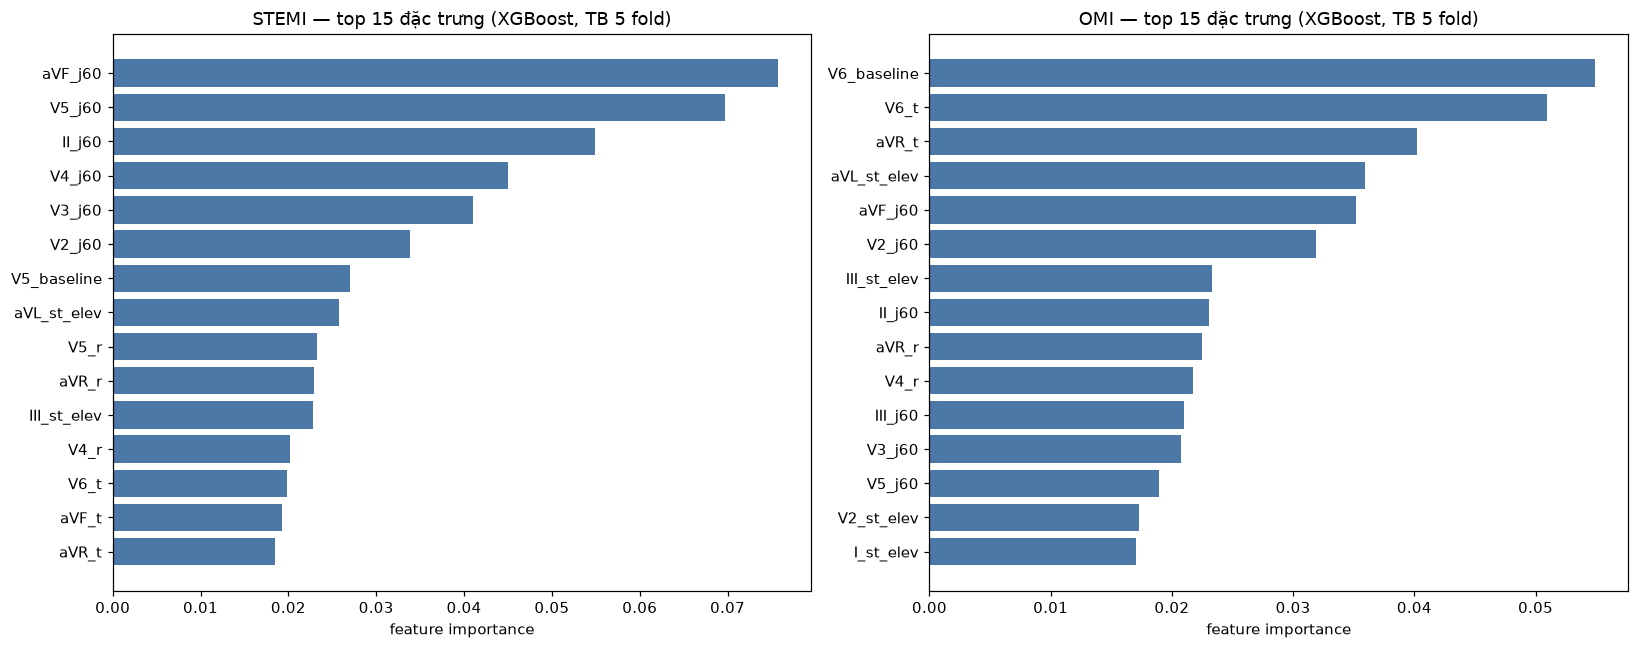

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, problem in zip(axes, PROBLEMS):
    y = Y[problem]
    importances = []
    for k, (tr, va) in FOLDS[problem].items():
        n_pos = int(y[tr].sum())
        pw = float((len(tr) - n_pos) / max(n_pos, 1))
        pipe = make_models(pw)["XGBoost"]
        pipe.fit(X_ALL[tr], y[tr])
        importances.append(pipe.named_steps["clf"].feature_importances_)
    imp = pd.Series(np.mean(importances, axis=0), index=FEATURE_COLS).sort_values(ascending=False)
    top = imp.head(15)
    ax.barh(top.index[::-1], top.values[::-1], color="#4C78A8")
    ax.set_title(f"{problem} — top 15 đặc trưng (XGBoost, TB 5 fold)")
    ax.set_xlabel("feature importance")
plt.tight_layout()
plt.show()

## 17. Lưu ý khi kết luận

- **So sánh ML vs DL ở mục 15 dựa trên giả định fold trùng khớp** giữa notebook này và `08`/`09` —
  không có cách xác minh trực tiếp trong notebook này (không nạp lại checkpoint DL), chỉ đúng nếu
  `train.csv` và mã chia fold không đổi.
- **Đặc trưng dùng cửa sổ cố định quanh R-peak**, không phải delineate đầy đủ — bền hơn nhưng thô hơn
  cách bác sĩ đọc thủ công (không phân biệt được hình dạng đoạn ST cong lên/xuống/nằm ngang, chỉ đo
  biên độ tại 1 điểm).
- **`n_beats` phụ thuộc chất lượng dò R-peak trên chuyển đạo II** — bản ghi nhiễu nặng hoặc lead II
  hỏng sẽ cho đặc trưng NaN, được impute bằng median của fold — có thể làm mất tín hiệu thật ở nhóm
  nhiễu nhiều.
- **Ngưỡng Youden's J chọn trên chính fold đang đánh giá** — Sensitivity/Specificity/F1 báo cáo có
  thể lạc quan hơn một chút so với ngưỡng chọn từ dữ liệu độc lập (giống hạn chế đã nêu ở `08`/`09`).
- **Tập test ẩn 10% không được chạm tới** ở bất kỳ bước nào.